In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

df = pd.read_csv("data/lightcast_job_postings.csv", low_memory=False)
df.head()



,ID,LAST_UPDATED_DATE,LAST_UPDATED_TIMESTAMP,DUPLICATES,POSTED,EXPIRED,DURATION,SOURCE_TYPES,SOURCES,URL,...,NAICS_2022_2,NAICS_2022_2_NAME,NAICS_2022_3,NAICS_2022_3_NAME,NAICS_2022_4,NAICS_2022_4_NAME,NAICS_2022_5,NAICS_2022_5_NAME,NAICS_2022_6,NAICS_2022_6_NAME
0,1f57d95acf4dc67ed2819eb12f049f6a5c11782c,9/6/2024,2024-09-06 20:32:57.352 Z,0.0,6/2/2024,6/8/2024,6.0,"[\n ""Company""\n]","[\n ""brassring.com""\n]","[\n ""https://sjobs.brassring.com/TGnewUI/Sear...",...,44.0,Retail Trade,441.0,Motor Vehicle and Parts Dealers,4413.0,"Automotive Parts, Accessories, and Tire Retailers",44133.0,Automotive Parts and Accessories Retailers,441330.0,Automotive Parts and Accessories Retailers
1,0cb072af26757b6c4ea9464472a50a443af681ac,8/2/2024,2024-08-02 17:08:58.838 Z,0.0,6/2/2024,8/1/2024,NaN,"[\n ""Job Board""\n]","[\n ""maine.gov""\n]","[\n ""https://joblink.maine.gov/jobs/1085740""\n]",...,56.0,Administrative and Support and Waste Managemen...,561.0,Administrative and Support Services,5613.0,Employment Services,56132.0,Temporary Help Services,561320.0,Temporary Help Services
2,85318b12b3331fa490d32ad014379df01855c557,9/6/2024,2024-09-06 20:32:57.352 Z,1.0,6/2/2024,7/7/2024,35.0,"[\n ""Job Board""\n]","[\n ""dejobs.org""\n]","[\n ""https://dejobs.org/dallas-tx/data-analys...",...,52.0,Finance and Insurance,524.0,Insurance Carriers and Related Activities,5242.0,"Agencies, Brokerages, and Other Insurance Rela...",52429.0,Other Insurance Related Activities,524291.0,Claims Adjusting
3,1b5c3941e54a1889ef4f8ae55b401a550708a310,9/6/2024,2024-09-06 20:32:57.352 Z,1.0,6/2/2024,7/20/2024,48.0,"[\n ""Job Board""\n]","[\n ""disabledperson.com"",\n ""dejobs.org""\n]","[\n ""https://www.disabledperson.com/jobs/5948...",...,52.0,Finance and Insurance,522.0,Credit Intermediation and Related Activities,5221.0,Depository Credit Intermediation,52211.0,Commercial Banking,522110.0,Commercial Banking
4,cb5ca25f02bdf25c13edfede7931508bfd9e858f,6/19/2024,2024-06-19 07:00:00.000 Z,0.0,6/2/2024,6/17/2024,15.0,"[\n ""FreeJobBoard""\n]","[\n ""craigslist.org""\n]","[\n ""https://modesto.craigslist.org/sls/77475...",...,99.0,Unclassified Industry,999.0,Unclassified Industry,9999.0,Unclassified Industry,99999.0,Unclassified Industry,999999.0,Unclassified Industry


In [7]:
df = df[df["SALARY"].notna()]
df["SALARY"] = df["SALARY"].astype(float)

print("Total rows with salary:", len(df))


Total rows with salary: 30808


In [10]:
df["PRIMARY_SECTOR"] = df["LIGHTCAST_SECTORS_NAME"].str.split(",").str[0].str.replace('"','').str.strip()

industry_salary = (
    df.groupby("NAICS2_NAME")["SALARY"]
    .median()
    .sort_values(ascending=False)
    .head(10)
)

industry_salary




NAICS2_NAME
Accommodation and Food Services                     149850.0
Information                                         132600.0
Professional, Scientific, and Technical Services    130000.0
Manufacturing                                       121300.0
Retail Trade                                        119925.0
Finance and Insurance                               118100.0
Construction                                        118097.5
Utilities                                           114950.0
Unclassified Industry                               105000.0
Management of Companies and Enterprises             101400.0
Name: SALARY, dtype: float64

/tmp/ipykernel_4941/1972646732.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


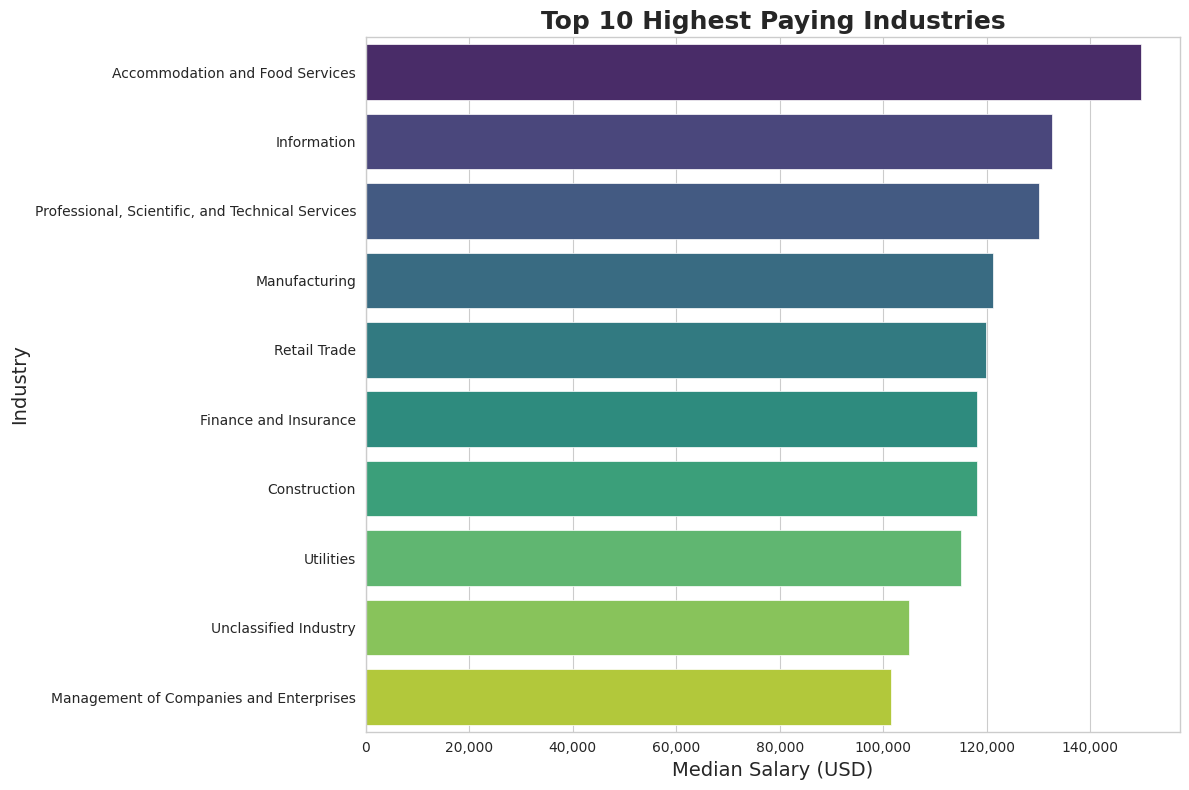

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

sns.set_style("whitegrid")  

plt.figure(figsize=(12,8))

ax = sns.barplot(
    x=industry_salary.values,
    y=industry_salary.index,
    palette="viridis"
)

# Title & labels
plt.title("Top 10 Highest Paying Industries", fontsize=18, weight="bold")
plt.xlabel("Median Salary (USD)", fontsize=14)
plt.ylabel("Industry", fontsize=14)

# Add comma formatting to the x-axis
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Tight layout for spacing
plt.tight_layout()

plt.show()



Industry Salary Insights

The chart above highlights the ten highest-paying industries in the labor market based on median salary levels. Accommodation and Food Services unexpectedly ranks at the top, driven largely by high-salary executive, managerial, and corporate leadership roles within major hospitality and food-service corporations. Industries such as Information and Professional, Scientific, and Technical Services also appear at the top of the salary distribution, reflecting the strong demand for specialized technical skills, data expertise, and management roles within these sectors.

Manufacturing, Retail Trade, Finance and Insurance, and Construction also maintain competitive median salaries, indicating continued economic strength and a need for skilled workers across technical and operational roles. Even industries like Utilities and Unclassified Industry categories show high median pay, often influenced by regulated wages, unionized labor, and specialized technical positions. Overall, the ranking demonstrates that high salaries are not limited to traditional white-collar fields, many essential and operational industries continue to offer substantial earning potential in today’s job market.